In [1]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ActivationAndGradientExtractor:
    def __init__(self, target_layer):
        self.activations = None
        self.gradients = None
        # Utilisation de full_backward_hook pour plus de stabilité
        self._forward_handle = target_layer.register_forward_hook(self._save_activation)
        self._backward_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        # grad_output[0] contient les gradients par rapport à la sortie de la couche
        self.gradients = grad_output[0].detach()

    def clear(self):
        self.activations = None
        self.gradients = None

print(f"Target Device: {DEVICE}")

Target Device: cuda


In [ ]:
def load_model_and_image():
    try:
        model_yolo = YOLO("yolov8n.pt").to(DEVICE)
        print("YOLOv8n model loaded")
        model_pt = model_yolo.model.eval()

        image_path = "2008_000152.jpg"
        image = cv2.imread(image_path)
             
        if image is None:
            raise FileNotFoundError(f"Could not read image file at {image_path}")

        return model_yolo, model_pt, image, image_path
    except Exception as e:
        print(f"Error during loading: {e}")
        return None, None, None, None

def get_target_layer(model_pt):
    try:
        # Index 9 ou 12 sont souvent les meilleurs pour le backbone YOLOv8n
        target_layer = model_pt.model[9] 
        print(f"Grad-CAM target layer: {target_layer.__class__.__name__}")
        return target_layer
    except IndexError:
        return None

model_yolo, model_pt, input_image, img_path = load_model_and_image()
target_layer = get_target_layer(model_pt)

if model_pt and target_layer:
    extractor = ActivationAndGradientExtractor(target_layer)
else:
    extractor = None

YOLOv8n model loaded
Grad-CAM target layer: SPPF


In [3]:
def generate_manual_gradcam(model_yolo, model_pt, image, extractor):
    if extractor is None:
        return None, None
    
    extractor.clear()
    
    # 1) Préparation Tensor
    img_resized = cv2.resize(image, (640, 640))
    rgb_img = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    input_tensor = torch.from_numpy(rgb_img).float().permute(2, 0, 1).unsqueeze(0).div(255.0).to(DEVICE)
    input_tensor.requires_grad_(True)

    # 2) Identification de la classe cible avec YOLO
    results = model_yolo(image, verbose=False)
    if len(results[0].boxes) == 0:
        print("Aucun objet détecté.")
        return None, None

    box_data = results[0].boxes[0]
    target_class_index = int(box_data.cls.cpu().item())
    target_class_name = results[0].names[target_class_index]
    print(f"Cible : {target_class_name} (ID: {target_class_index})")

    # 3) Forward Pass
    output = model_pt(input_tensor)
    print(f"Forme brute de la sortie : {output[0].shape}") 
    # Doit afficher: torch.Size([1, 84, 8400]) si tu as 80 classes (4 coord + 80 classes)
    
    nb_anchors = output[0].shape[2]
    print(f"Nombre d'ancres détectées : {nb_anchors}")
    # --- MODIFICATION ICI ---
    # La sortie YOLOv8 est [1, 4 + nb_classes, 8400]
    # On accède au canal (4 + index_classe) et on prend le max parmi les 8400 ancres
    try:
        class_scores = output[0][0, 4 + target_class_index, :]
        target_score_tensor = torch.max(class_scores)
    except IndexError:
        print("Erreur d'indexation du tenseur de sortie.")
        return None, None
    # -------------------------

    # 4) Backward Pass
    model_pt.zero_grad()
    target_score_tensor.backward(retain_graph=True)

    # 5) Calcul des poids
    weights = torch.mean(extractor.gradients, dim=(2, 3), keepdim=True)

    # 6) Somme pondérée
    cam = torch.sum(weights * extractor.activations, dim=1).squeeze()
    cam = F.relu(cam)

    # 7) Normalisation
    cam_np = cam.cpu().numpy()
    if cam_np.max() > 0:
        cam_np = cam_np / cam_np.max()

    # 8) Redimensionnement et Superposition
    h, w, _ = image.shape
    cam_resized = cv2.resize(cam_np, (w, h))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(img_rgb, 0.7, heatmap_rgb, 0.3, 0)

    # 9) Bounding Box
    x1, y1, x2, y2 = box_data.xyxy[0].cpu().numpy().astype(int)
    cv2.rectangle(superimposed, (x1, y1), (x2, y2), (0, 0, 255), 10)
    cv2.putText(superimposed, target_class_name, (x1, y1 - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (200, 200, 0), 2)

    return superimposed, target_class_name

Cible : elephant (ID: 20)
Forme brute de la sortie : torch.Size([1, 84, 8400])
Nombre d'ancres détectées : 8400


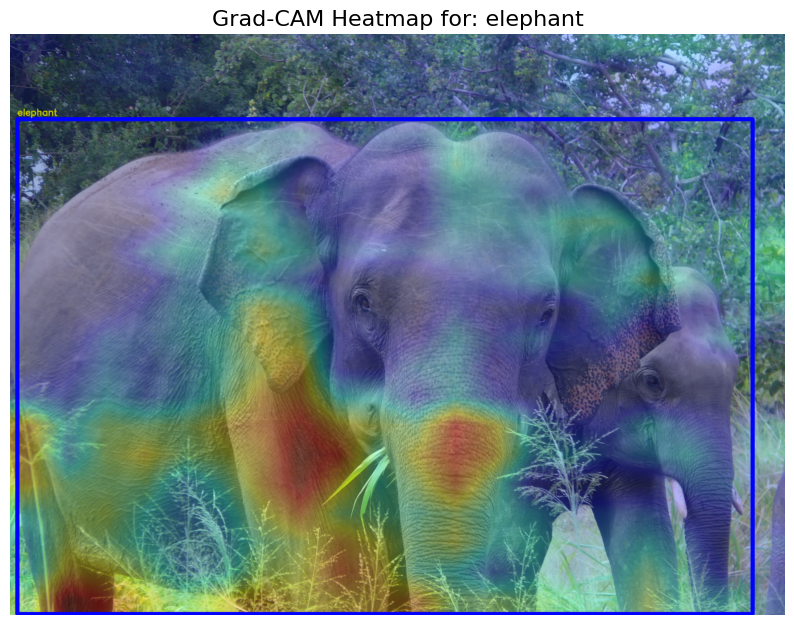

In [4]:
if model_pt and input_image is not None and extractor:
    grad_cam_image_rgb, target_name = generate_manual_gradcam(
        model_yolo, model_pt, input_image, extractor
    )

    if grad_cam_image_rgb is not None:
        plt.figure(figsize=(10, 10))
        plt.imshow(grad_cam_image_rgb)
        plt.title(f"Grad-CAM Heatmap for: {target_name}", fontsize=16)
        plt.axis("off")
        plt.show()
else:
    print(
        "\nThe cell execution requires a model and an image"
    )